In [2]:
import numpy as np
import open3d as o3d
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
import matplotlib.cm as cm
from nuscenes.nuscenes import NuScenes
from nuscenes.utils.data_classes import LidarPointCloud
from nuscenes.utils.geometry_utils import view_points
from pyquaternion import Quaternion
import os
from sklearn.cluster import DBSCAN

# Camera-LiDAR Sensor Fusion

Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 0.291 seconds.
Reverse indexing ...
Done reverse indexing in 0.0 seconds.
saved 0
saved 5
saved 10
saved 15
saved 20
saved 25
saved 30
saved 35


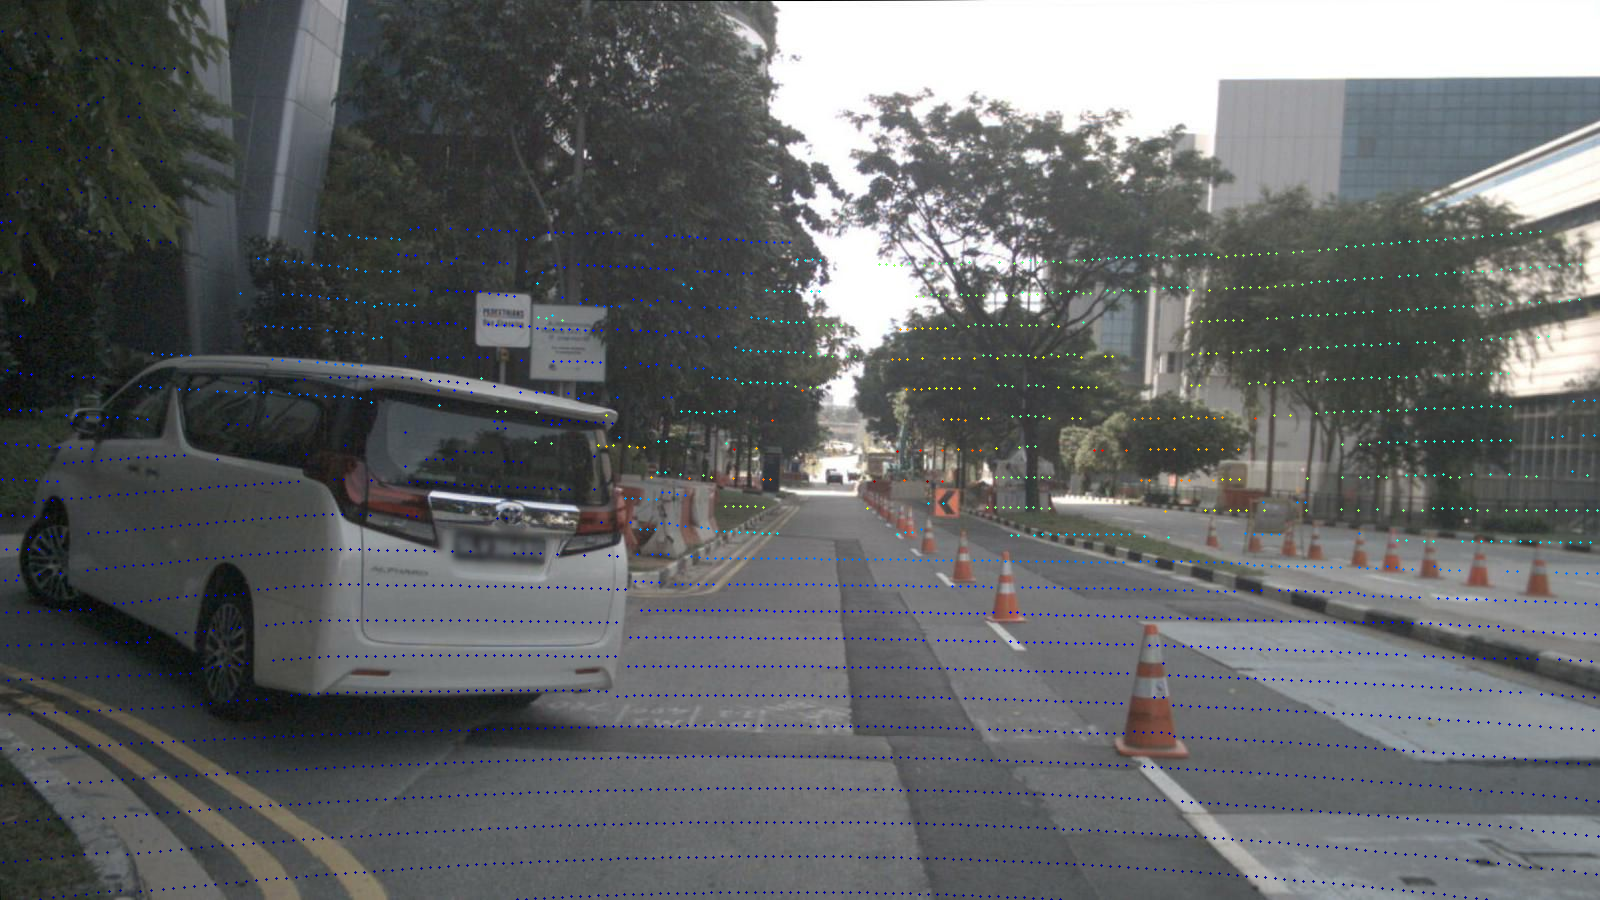

In [3]:
# load dataset
nusc = NuScenes(version="v1.0-mini", dataroot="archive", verbose=True)

os.makedirs("fusion_results", exist_ok=True)

# --------------------------------
# first sample
# --------------------------------
scene = nusc.scene[0]
sample = nusc.get("sample", scene["first_sample_token"])

frame_id = 0

while sample is not None:

    if frame_id % 5 == 0:

        cam_token = sample["data"]["CAM_FRONT"]
        lidar_token = sample["data"]["LIDAR_TOP"]

        cam_sd = nusc.get("sample_data", cam_token)
        lidar_sd = nusc.get("sample_data", lidar_token)

        # image
        img = Image.open(nusc.dataroot + "/" + cam_sd["filename"])

        # lidar
        pc = LidarPointCloud.from_file(nusc.dataroot + "/" + lidar_sd["filename"])

        # --------------------------------
        # lidar -> ego
        # --------------------------------
        cs_lidar = nusc.get("calibrated_sensor", lidar_sd["calibrated_sensor_token"])
        pc.rotate(Quaternion(cs_lidar["rotation"]).rotation_matrix)
        pc.translate(np.array(cs_lidar["translation"]))

        # --------------------------------
        # ego -> global
        # --------------------------------
        pose_lidar = nusc.get("ego_pose", lidar_sd["ego_pose_token"])
        pc.rotate(Quaternion(pose_lidar["rotation"]).rotation_matrix)
        pc.translate(np.array(pose_lidar["translation"]))

        # --------------------------------
        # global -> camera ego
        # --------------------------------
        pose_cam = nusc.get("ego_pose", cam_sd["ego_pose_token"])
        pc.translate(-np.array(pose_cam["translation"]))
        pc.rotate(Quaternion(pose_cam["rotation"]).rotation_matrix.T)

        # --------------------------------
        # ego -> camera
        # --------------------------------
        cs_cam = nusc.get("calibrated_sensor", cam_sd["calibrated_sensor_token"])
        pc.translate(-np.array(cs_cam["translation"]))
        pc.rotate(Quaternion(cs_cam["rotation"]).rotation_matrix.T)

        # project
        points = view_points(pc.points[:3, :], np.array(cs_cam["camera_intrinsic"]), normalize=True)

        # --------------------------------
        # keep valid points
        # --------------------------------
        depths = pc.points[2, :]

        mask = depths > 1

        mask &= (points[0, :] > 0)
        mask &= (points[0, :] < img.size[0])

        mask &= (points[1, :] > 0)
        mask &= (points[1, :] < img.size[1])

        points = points[:, mask]
        depths = depths[mask]

        # --------------------------------
        # draw
        # --------------------------------
        img_draw = img.copy()
        draw = ImageDraw.Draw(img_draw)
        
        depth_min = depths.min()
        depth_max = depths.max()
        
        for x, y, d in zip(points[0,:], points[1,:], depths):
        
            # normalize depth
            norm_d = (d - depth_min) / (depth_max - depth_min)
        
            # colormap
            color = cm.jet(norm_d)
        
            rgb = (int(color[0] * 255), int(color[1] * 255), int(color[2] * 255))
        
            draw.ellipse((x-1, y-1, x+1, y+1), fill=rgb)
        
        img_draw.save(f"fusion_results/fusion_{frame_id:03d}.jpg")

        print("saved", frame_id)
        
        if  frame_id == 35:
            img_draw.show()

        

    if sample["next"] == "":
        break

    sample = nusc.get("sample", sample["next"])

    frame_id += 1

# Point Cloud Processing using Open3D and Scikit-Learn

Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 0.219 seconds.
Reverse indexing ...
Done reverse indexing in 0.0 seconds.
Original points: 34688
After voxel: 9917
After outlier removal: 9585
Ground points: 2979
Object points: 6606
Clusters found: 23


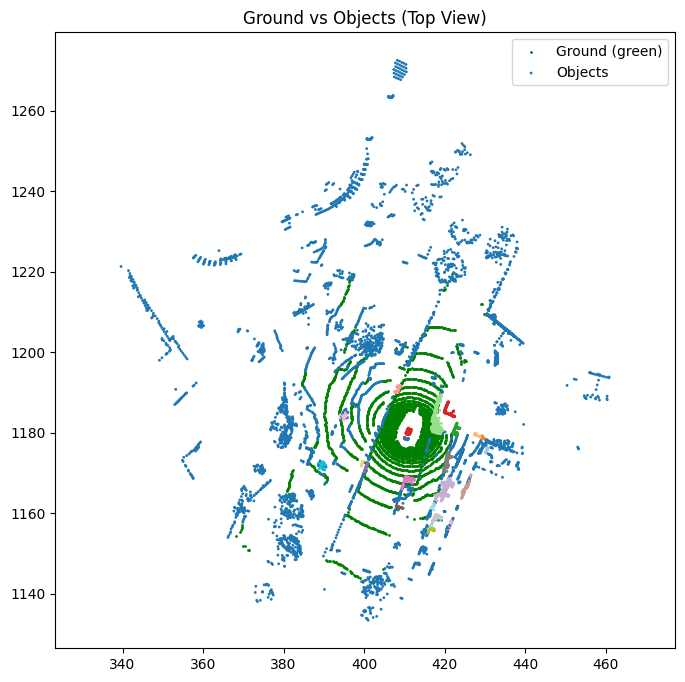

In [4]:
# OUTPUT
os.makedirs("results/visualizations", exist_ok=True)

# LOAD DATASET
nusc = NuScenes(version="v1.0-mini", dataroot="archive", verbose=True)

# ====================================
# FIRST SAMPLE
# ====================================
scene = nusc.scene[0]
sample = nusc.get("sample", scene["first_sample_token"])

# ====================================
# LOAD LIDAR
# ====================================
lidar_token = sample["data"]["LIDAR_TOP"]
sd = nusc.get("sample_data", lidar_token)
pc = LidarPointCloud.from_file(nusc.dataroot + "/" + sd["filename"])

# ====================================
# LIDAR -> EGO
# ====================================
cs = nusc.get("calibrated_sensor", sd["calibrated_sensor_token"])
pc.rotate(Quaternion(cs["rotation"]).rotation_matrix)
pc.translate(np.array(cs["translation"]))

# ====================================
# EGO -> GLOBAL
# ====================================
pose = nusc.get("ego_pose", sd["ego_pose_token"])
pc.rotate(Quaternion(pose["rotation"]).rotation_matrix)
pc.translate(np.array(pose["translation"]))

points = pc.points[:3, :].T
print("Original points:", len(points))

# ====================================
# OPEN3D CLOUD
# ====================================
cloud = o3d.geometry.PointCloud()
cloud.points = o3d.utility.Vector3dVector(points)

# ====================================
# VOXEL DOWNSAMPLING
# ====================================
cloud_down = cloud.voxel_down_sample(voxel_size=0.3)
print("After voxel:", len(cloud_down.points))

# ====================================
# OUTLIER REMOVAL
# ====================================
cloud_clean, ind = cloud_down.remove_statistical_outlier(nb_neighbors=20, std_ratio=2.0)
print("After outlier removal:", len(cloud_clean.points))

# ====================================
# GROUND PLANE REMOVAL
# ====================================
plane_model, inliers = cloud_clean.segment_plane(distance_threshold=0.20, ransac_n=3, num_iterations=1000)
ground = cloud_clean.select_by_index(inliers)
objects = cloud_clean.select_by_index(inliers, invert=True)
print("Ground points:", len(ground.points))
print("Object points:", len(objects.points))

# ====================================
# DBSCAN CLUSTERING
# ====================================
points = np.asarray(objects.points)
labels = DBSCAN(eps=1.0, min_samples=20).fit_predict(points)
max_label = labels.max()
print("Clusters found:", max_label + 1)

# ====================================
# COLOR CLUSTERS
# ====================================
colors = plt.get_cmap("tab20")(labels / (max_label + 1))
colors[labels < 0] = [0, 0, 0, 1]
objects.colors = o3d.utility.Vector3dVector(colors[:, :3])

# ====================================
# SAVE RESULTS
# ====================================
o3d.io.write_point_cloud("results/visualizations/original.pcd", cloud)
o3d.io.write_point_cloud("results/visualizations/downsampled.pcd", cloud_down)
o3d.io.write_point_cloud("results/visualizations/clean.pcd", cloud_clean)
o3d.io.write_point_cloud("results/visualizations/ground.pcd", ground)
o3d.io.write_point_cloud("results/visualizations/clusters.pcd", objects)

# ====================================
# VISUALIZATION
# ====================================
ground_points = np.asarray(ground.points)
object_points = np.asarray(objects.points)

plt.figure(figsize=(8,8))
plt.scatter(ground_points[:,0], ground_points[:,1], c="green", s=1, label="Ground (green)")
plt.scatter(object_points[:,0], object_points[:,1], c=labels, s=1, cmap="tab20", label="Objects")
plt.axis("equal")
plt.legend()
plt.title("Ground vs Objects (Top View)")
plt.savefig("results/visualizations/topview_ground_objects.png", dpi=300)
plt.show()
plt.close()